In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

# Saudi Aramco Discounted Cash Flow (DCF) Valuation Model
This notebook calculates the intrinsic value of Saudi Aramco based on Free Cash Flow (FCF) projections.

In [65]:
# Fetch Aramco stock data
ticker = "2222.SR"
aramco = yf.Ticker(ticker)
 
# Get current stock price
current_price = aramco.history(period="1d")['Close'].iloc[-1]
print(f"Current Aramco Stock Price: {current_price:.2f} SAR")
print(f"Date: {datetime.now().strftime('%Y-%m-%d')}")
print("\n" + "="*70 + "\n")


Current Aramco Stock Price: 26.88 SAR
Date: 2026-06-15




In [66]:
print("ASSUMPTIONS")
print("="*70)
 
# Revenue & FCF
latest_revenue_billions_sar = 1650  # 2023 revenue ~$440B USD x 3.75 SAR/USD
latest_fcf_conversion = 0.22        # FCF as % of revenue (historical: ~20-25%)
 
# Discount rate & growth
wacc = 0.08           # Weighted average cost of capital
terminal_growth = 0.025  # Long-term perpetual growth (2-3%)
 
# Balance sheet inputs
net_debt_billions = 90               # 2023: ~$24B USD net debt x 3.75 SAR/USD
shares_outstanding_billions = 213.4  # Aramco shares outstanding
 
# Revenue growth projections
revenue_growth_rates = [0.05, 0.04, 0.03, 0.03, 0.02]  # Years 1-5: declining growth
 
# Margin assumptions
ebitda_margin = 0.40  # EBITDA as % of revenue (Aramco: ~38-42%)
 
print(f"Latest Revenue (SAR billions): {latest_revenue_billions_sar}")
print(f"EBITDA Margin: {ebitda_margin*100:.1f}%")
print(f"FCF Conversion to Revenue: {latest_fcf_conversion*100:.1f}%")
print(f"WACC (Discount Rate): {wacc*100:.1f}%")
print(f"Terminal Growth Rate: {terminal_growth*100:.1f}%")
print(f"Net Debt (SAR billions): {net_debt_billions}")
print(f"Shares Outstanding (billions): {shares_outstanding_billions}")
print(f"\nRevenue Growth Rates (Year 1-5): {[f'{x*100:.1f}%' for x in revenue_growth_rates]}")
print("\n" + "="*70 + "\n")

ASSUMPTIONS
Latest Revenue (SAR billions): 1650
EBITDA Margin: 40.0%
FCF Conversion to Revenue: 22.0%
WACC (Discount Rate): 8.0%
Terminal Growth Rate: 2.5%
Net Debt (SAR billions): 90
Shares Outstanding (billions): 213.4

Revenue Growth Rates (Year 1-5): ['5.0%', '4.0%', '3.0%', '3.0%', '2.0%']




In [67]:
print("5-YEAR REVENUE & EBITDA PROJECTIONS")
print("="*70)
 
years = np.arange(1, 6)
revenues = []
ebitdas = []
 
# Base year
revenue = latest_revenue_billions_sar
 
for i, growth_rate in enumerate(revenue_growth_rates):
    revenue = revenue * (1 + growth_rate)
    ebitda = revenue * ebitda_margin
    revenues.append(revenue)
    ebitdas.append(ebitda)
    print(f"Year {i+1}: Revenue = {revenue:.1f}B SAR | EBITDA = {ebitda:.1f}B SAR | Growth = {growth_rate*100:.1f}%")
 
revenues = np.array(revenues)
ebitdas = np.array(ebitdas)
print("\n" + "="*70 + "\n")

5-YEAR REVENUE & EBITDA PROJECTIONS
Year 1: Revenue = 1732.5B SAR | EBITDA = 693.0B SAR | Growth = 5.0%
Year 2: Revenue = 1801.8B SAR | EBITDA = 720.7B SAR | Growth = 4.0%
Year 3: Revenue = 1855.9B SAR | EBITDA = 742.3B SAR | Growth = 3.0%
Year 4: Revenue = 1911.5B SAR | EBITDA = 764.6B SAR | Growth = 3.0%
Year 5: Revenue = 1949.8B SAR | EBITDA = 779.9B SAR | Growth = 2.0%




In [68]:
print("FREE CASH FLOW PROJECTIONS (5-Year)")
print("="*70)
 
# FCF = Revenue × FCF Conversion Rate (22% of revenue)
# Bug fix: was previously applied to EBITDA, which double-applied the margin reduction
 
fcfs = revenues * latest_fcf_conversion
 
for i, fcf in enumerate(fcfs):
    print(f"Year {i+1} FCF: {fcf:.2f}B SAR")
 
print("\n" + "="*70 + "\n")

FREE CASH FLOW PROJECTIONS (5-Year)
Year 1 FCF: 381.15B SAR
Year 2 FCF: 396.40B SAR
Year 3 FCF: 408.29B SAR
Year 4 FCF: 420.54B SAR
Year 5 FCF: 428.95B SAR




In [69]:
print("DISCOUNTED CASH FLOWS")
print("="*70)
 
discount_factors = (1 + wacc) ** years
pv_fcfs = fcfs / discount_factors
 
total_pv_fcfs = pv_fcfs.sum()
 
for i, (fcf, df, pv) in enumerate(zip(fcfs, discount_factors, pv_fcfs)):
    print(f"Year {i+1}: FCF = {fcf:.2f}B SAR | Discount Factor = {df:.4f} | PV = {pv:.2f}B SAR")
 
print(f"\nTotal PV of 5-Year FCFs: {total_pv_fcfs:.2f}B SAR")
print("\n" + "="*70 + "\n")

DISCOUNTED CASH FLOWS
Year 1: FCF = 381.15B SAR | Discount Factor = 1.0800 | PV = 352.92B SAR
Year 2: FCF = 396.40B SAR | Discount Factor = 1.1664 | PV = 339.85B SAR
Year 3: FCF = 408.29B SAR | Discount Factor = 1.2597 | PV = 324.11B SAR
Year 4: FCF = 420.54B SAR | Discount Factor = 1.3605 | PV = 309.11B SAR
Year 5: FCF = 428.95B SAR | Discount Factor = 1.4693 | PV = 291.93B SAR

Total PV of 5-Year FCFs: 1617.92B SAR




In [70]:
print("TERMINAL VALUE & VALUATION")
print("="*70)
 
# Terminal value = Year 5 FCF x (1 + g) / (WACC - g)
terminal_fcf = fcfs[-1] * (1 + terminal_growth)
terminal_value = terminal_fcf / (wacc - terminal_growth)
discount_factor_terminal = (1 + wacc) ** 5
pv_terminal_value = terminal_value / discount_factor_terminal
 
print(f"Year 5 FCF: {fcfs[-1]:.2f}B SAR")
print(f"Terminal Growth Rate: {terminal_growth*100:.1f}%")
print(f"Terminal Value (Year 5): {terminal_value:.2f}B SAR")
print(f"Discount Factor (Year 5): {discount_factor_terminal:.4f}")
print(f"PV of Terminal Value: {pv_terminal_value:.2f}B SAR")
print("\n" + "-"*70 + "\n")
 
# Enterprise Value -> Equity Value -> Per Share
enterprise_value = total_pv_fcfs + pv_terminal_value
equity_value = enterprise_value - net_debt_billions
intrinsic_price = equity_value / shares_outstanding_billions
 
print(f"Enterprise Value: {enterprise_value:.2f}B SAR")
print(f"Net Debt: {net_debt_billions:.2f}B SAR")
print(f"Equity Value: {equity_value:.2f}B SAR")
print(f"\nShares Outstanding: {shares_outstanding_billions:.1f}B")
print(f"Intrinsic Price per Share: {intrinsic_price:.2f} SAR")
print(f"Current Market Price: {current_price:.2f} SAR")
upside = ((intrinsic_price - current_price) / current_price) * 100
print(f"Upside/(Downside): {upside:+.1f}%")
print("\n" + "="*70 + "\n")

TERMINAL VALUE & VALUATION
Year 5 FCF: 428.95B SAR
Terminal Growth Rate: 2.5%
Terminal Value (Year 5): 7994.02B SAR
Discount Factor (Year 5): 1.4693
PV of Terminal Value: 5440.59B SAR

----------------------------------------------------------------------

Enterprise Value: 7058.51B SAR
Net Debt: 90.00B SAR
Equity Value: 6968.51B SAR

Shares Outstanding: 213.4B
Intrinsic Price per Share: 32.65 SAR
Current Market Price: 26.88 SAR
Upside/(Downside): +21.5%




In [71]:
print("SENSITIVITY ANALYSIS")
print("="*70)
print("\nIntrinsic Price Sensitivity to WACC and Terminal Growth\n")
 
# Range of assumptions
wacc_range = np.arange(0.06, 0.12, 0.01)  # 6% to 11%
growth_range = np.arange(0.01, 0.05, 0.005)  # 1% to 4.5%
 
# Create sensitivity table
sensitivity_table = np.zeros((len(wacc_range), len(growth_range)))
 
for i, wacc_sens in enumerate(wacc_range):
    for j, growth_sens in enumerate(growth_range):
        # Recalculate with different assumptions
        discount_factors_sens = (1 + wacc_sens) ** years
        pv_fcfs_sens = fcfs / discount_factors_sens
        total_pv_sens = pv_fcfs_sens.sum()
        
        terminal_fcf_sens = fcfs[-1] * (1 + growth_sens)
        terminal_value_sens = terminal_fcf_sens / (wacc_sens - growth_sens)
        pv_terminal_sens = terminal_value_sens / ((1 + wacc_sens) ** 5)
        
        enterprise_value_sens = total_pv_sens + pv_terminal_sens
        equity_value_sens = enterprise_value_sens - net_debt_billions
        intrinsic_price_sens = equity_value_sens / shares_outstanding_billions
        
        sensitivity_table[i, j] = intrinsic_price_sens
 
# Create DataFrame for better display
sensitivity_df = pd.DataFrame(
    sensitivity_table,
    index=[f"{x*100:.0f}%" for x in wacc_range],
    columns=[f"{x*100:.1f}%" for x in growth_range]
)
 
print(sensitivity_df.round(2))
print("\n(Values in SAR per share)")
print("\n" + "="*70 + "\n")

SENSITIVITY ANALYSIS

Intrinsic Price Sensitivity to WACC and Terminal Growth

      1.0%   1.5%   2.0%   2.5%   3.0%   3.5%   4.0%    4.5%
6%   37.93  41.47  45.89  51.57  59.16  69.77  85.69  112.23
7%   31.49  33.82  36.60  40.01  44.27  49.75  57.05   67.27
8%   26.90  28.52  30.42  32.65  35.34  38.62  42.73   48.00
9%   23.45  24.64  26.00  27.56  29.39  31.54  34.13   37.30
10%  20.77  21.67  22.68  23.83  25.13  26.64  28.40   30.48
11%  18.63  19.33  20.10  20.97  21.94  23.05  24.31   25.76

(Values in SAR per share)




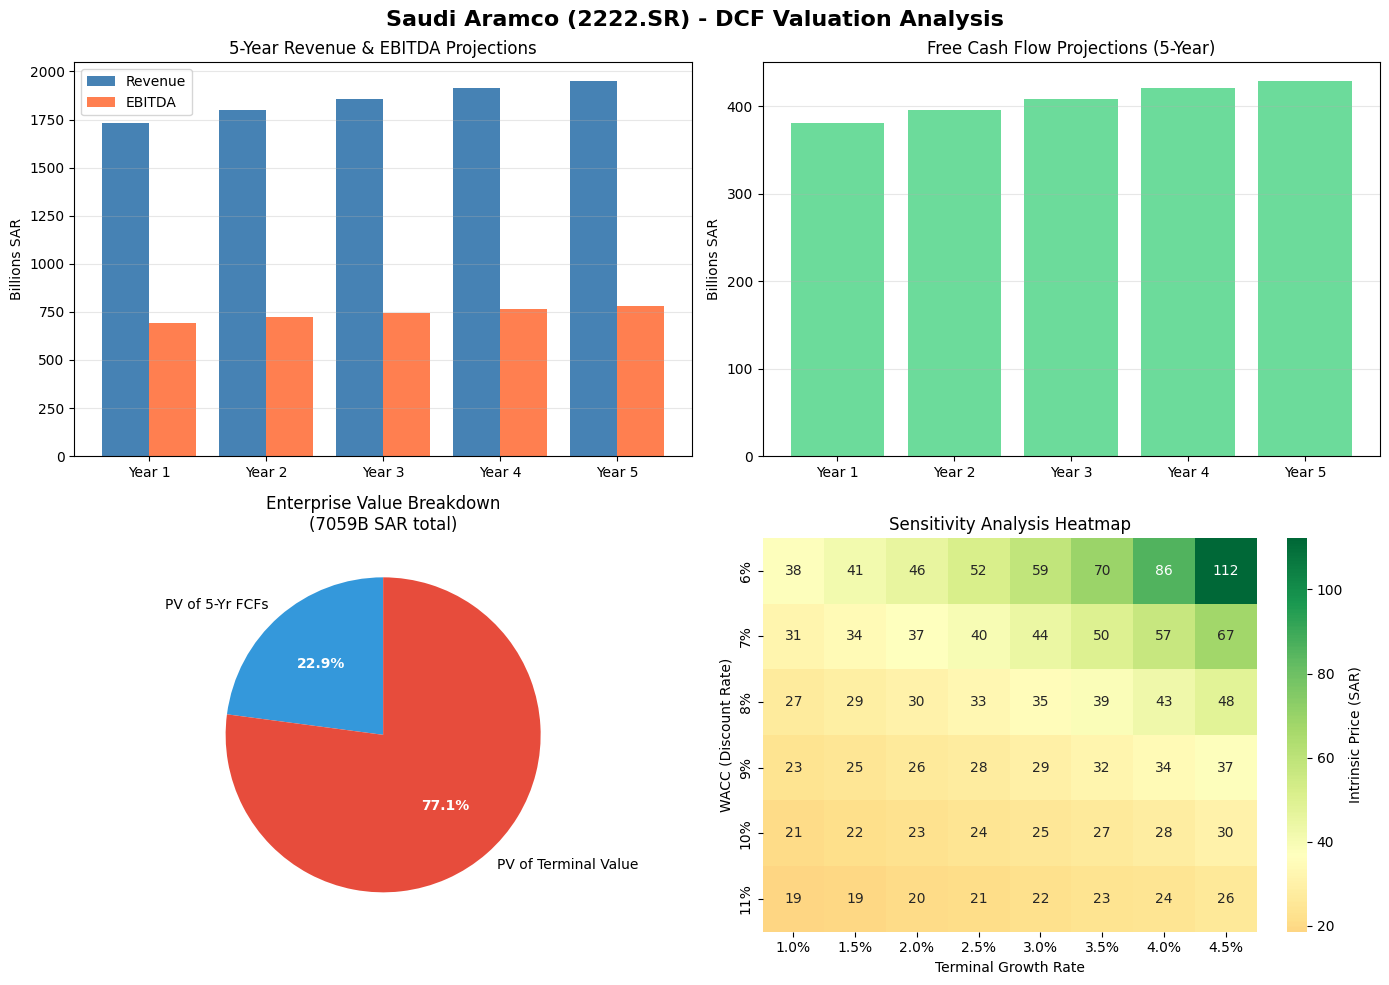

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Saudi Aramco (2222.SR) - DCF Valuation Analysis', fontsize=16, fontweight='bold')
 
# Plot 1: Revenue & EBITDA Projections
ax1 = axes[0, 0]
years_labels = [f'Year {i}' for i in range(1, 6)]
ax1.bar(np.arange(len(years_labels)) - 0.2, revenues, 0.4, label='Revenue', color='steelblue')
ax1.bar(np.arange(len(years_labels)) + 0.2, ebitdas, 0.4, label='EBITDA', color='coral')
ax1.set_ylabel('Billions SAR')
ax1.set_title('5-Year Revenue & EBITDA Projections')
ax1.set_xticks(np.arange(len(years_labels)))
ax1.set_xticklabels(years_labels)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# Plot 2: FCF Projections
ax2 = axes[0, 1]
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in fcfs]
ax2.bar(years_labels, fcfs, color=colors, alpha=0.7)
ax2.set_ylabel('Billions SAR')
ax2.set_title('Free Cash Flow Projections (5-Year)')
ax2.grid(axis='y', alpha=0.3)
 
# Plot 3: Enterprise Value breakdown — 2 slices only (PV FCFs + PV TV = EV)
ax3 = axes[1, 0]
components = ['PV of 5-Yr FCFs', 'PV of Terminal Value']
values_pie = [total_pv_fcfs, pv_terminal_value]
colors_pie = ['#3498db', '#e74c3c']
wedges, texts, autotexts = ax3.pie(values_pie, labels=components, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90)
ax3.set_title(f'Enterprise Value Breakdown\n({enterprise_value:.0f}B SAR total)')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
 
# Plot 4: Sensitivity Heatmap
ax4 = axes[1, 1]
sns.heatmap(sensitivity_table, annot=True, fmt='.0f', cmap='RdYlGn',
            center=float(sensitivity_table.mean()),
            xticklabels=[f'{x*100:.1f}%' for x in growth_range],
            yticklabels=[f'{x*100:.0f}%' for x in wacc_range],
            ax=ax4, cbar_kws={'label': 'Intrinsic Price (SAR)'})
ax4.set_xlabel('Terminal Growth Rate')
ax4.set_ylabel('WACC (Discount Rate)')
ax4.set_title('Sensitivity Analysis Heatmap')
 
plt.tight_layout()